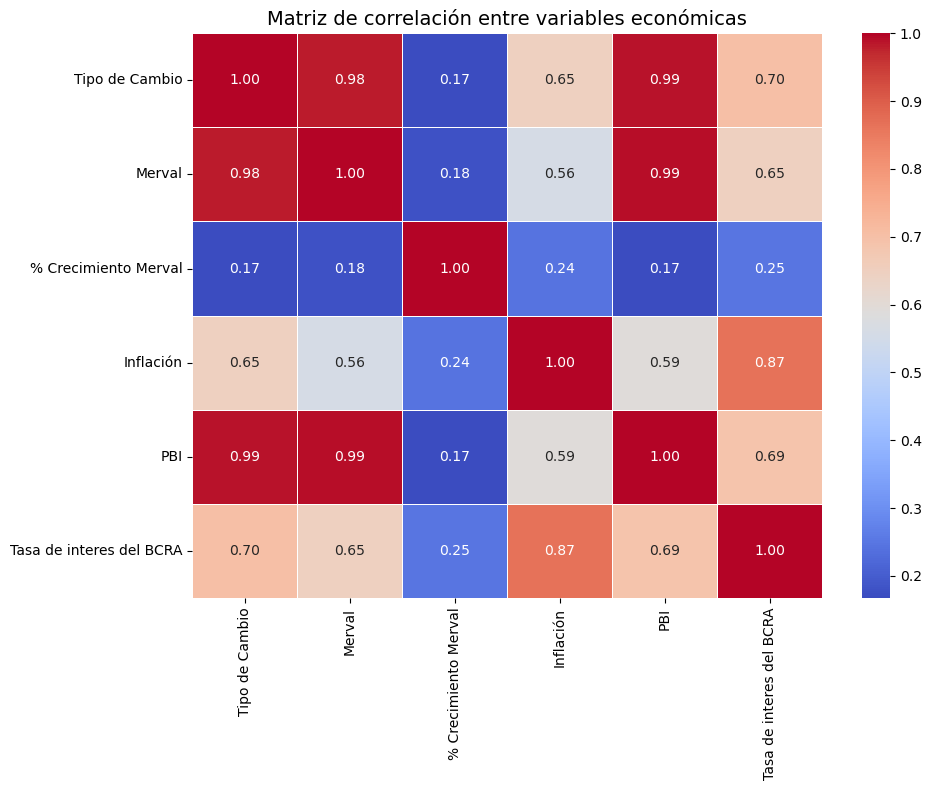

            Tipo de Cambio      Merval  % Crecimiento Merval  \
Fecha                                                          
2004-01-31           2.928  1140.81006              6.423818   
2004-02-29           2.923  1183.14001              3.710517   
2004-03-31           2.860  1201.66003              1.565328   
2004-04-30           2.840  1077.93005            -10.296588   
2004-05-31           2.960   952.62000            -11.625063   

            Tasa de interes del BCRA            PBI  
Fecha                                                
2004-01-31                  0.765475  439195.865000  
2004-02-29                  0.664918  462630.131082  
2004-03-31                  0.601411  486064.397165  
2004-04-30                  0.557234  509498.663247  
2004-05-31                  0.716298  502486.569695  
Index(['Tipo de Cambio', 'Merval', '% Crecimiento Merval', 'Inflación', 'PBI',
       'indice_tiempo', 'Tasa de interes del BCRA'],
      dtype='object')
Columnas disponible

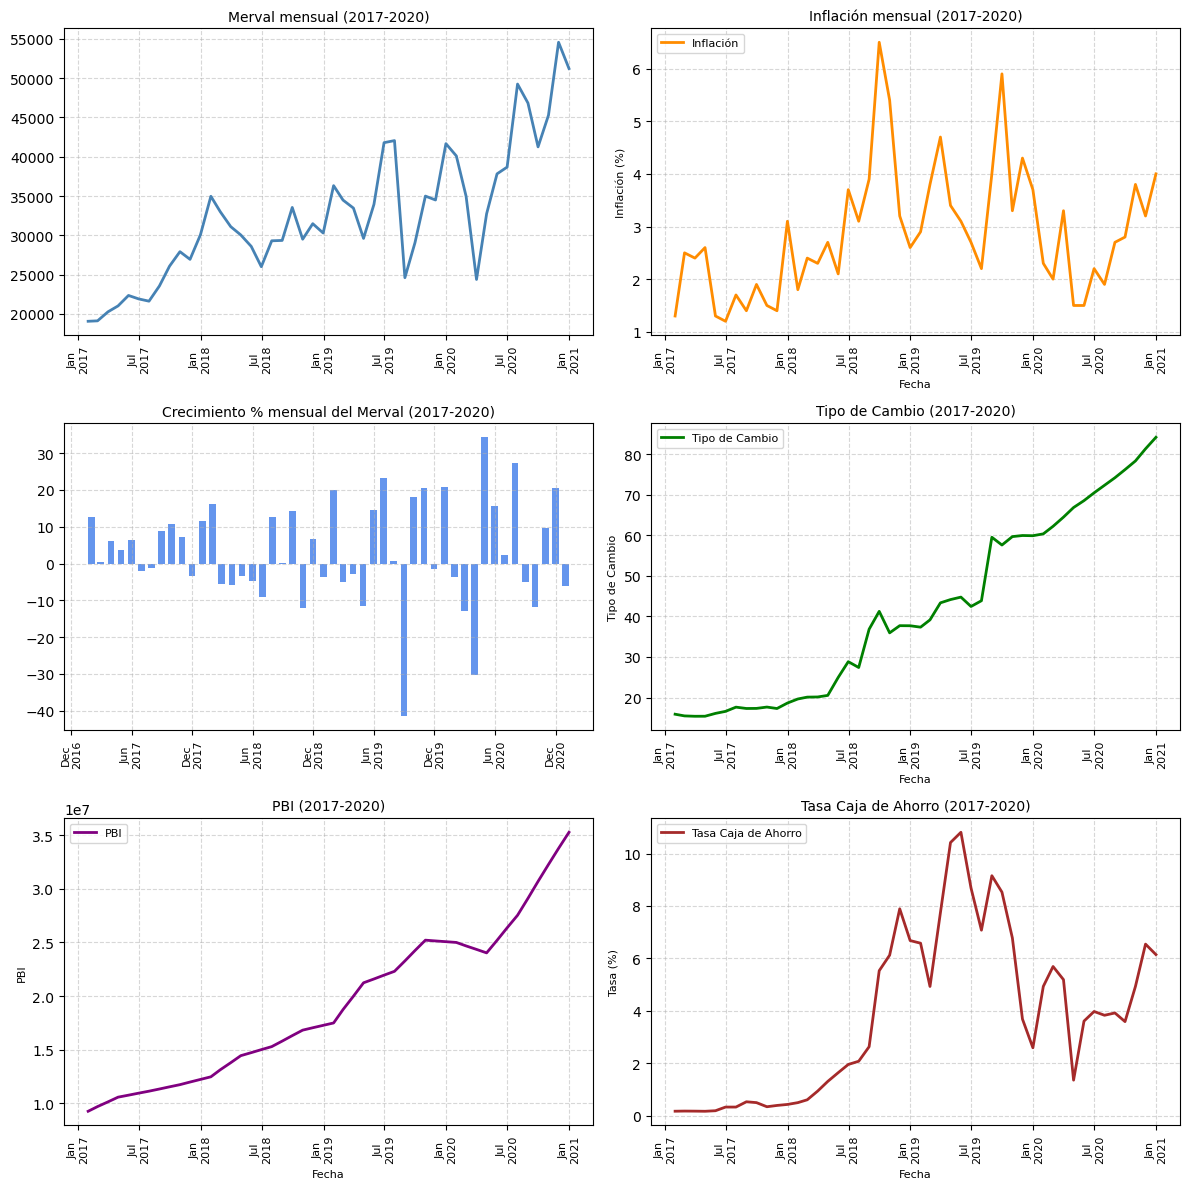

Columnas disponibles en df_slice (2021-2024): ['Tipo de Cambio', 'Merval', '% Crecimiento Merval', 'Inflación', 'PBI', 'indice_tiempo', 'Tasa de interes del BCRA']


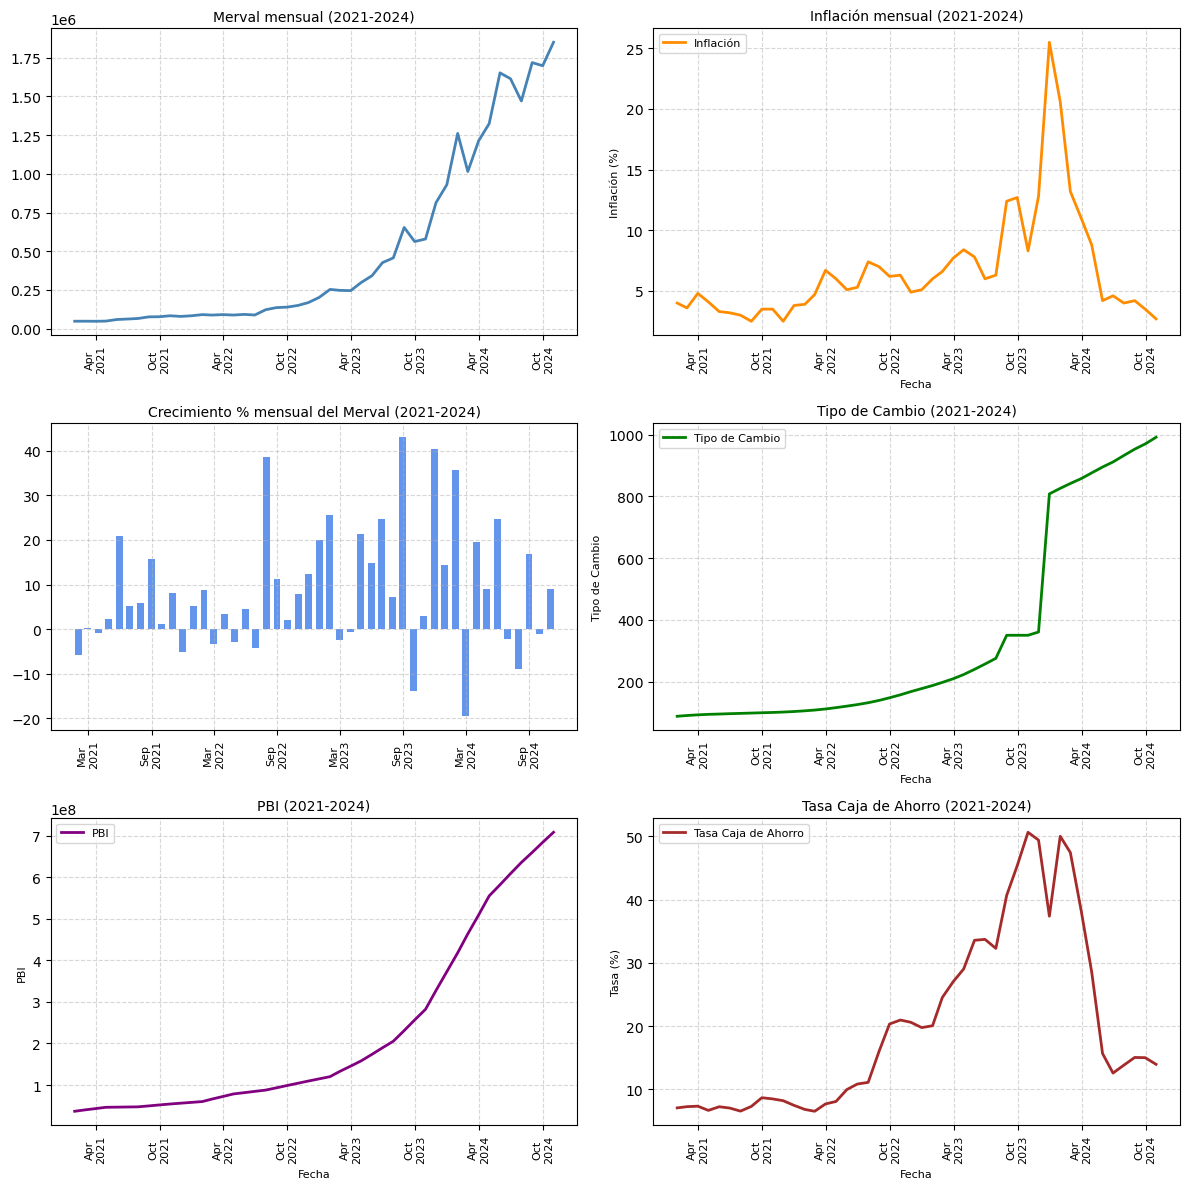

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
# -- Lectura de archivos principales ---es ---
dolar_df = pd.read_csv("tipos-de-cambio-historicos.csv")   
inflacion_df = pd.read_excel("D:/Mis documentos/Estudio/Lic en economia/2do Año/Big data & machine learning/Tps/TP Grupal/inflacion.xlsx")
merval_df = pd.read_csv("MERVAL - Cotizaciones historicas.csv")
pbi_df = pd.read_csv("producto-interno-bruto-precios-corrientes-valores-trimestrales-base-2004.csv")

# --- Filtrar columnas útiles para PBI ---
columnas_utiles_pbi = ['indice_tiempo', 'pbi']

def standardize_date_column(df, possible_columns):
    """Busca y renombra la columna de fecha a 'Fecha' si la encuentra."""
    for col in possible_columns:
        if col in df.columns:
            df['Fecha'] = pd.to_datetime(df[col], errors='coerce')
            return df
    print(f"Advertencia: No se encontró una columna de fecha estándar en el DataFrame. Columnas presentes: {df.columns}")
    return df

# --- Estandarización de columnas de fecha ---
dolar_df = standardize_date_column(dolar_df, ['indice_tiempo', 'Fecha'])
inflacion_df = standardize_date_column(inflacion_df, ['indice_tiempo', 'Fecha'])
merval_df = standardize_date_column(merval_df, ['fecha', 'Fecha']) # Buscamos 'fecha' primero
pbi_df = standardize_date_column(pbi_df, ['indice_tiempo', 'Fecha'])

# --- Preparación CLAVE para pbi_df: Establecer índice, remuestrear e interpolar ---
pbi_df.set_index('Fecha', inplace=True)
pbi_df = pbi_df[columnas_utiles_pbi[1:]].copy() # Seleccionamos solo la columna 'pbi', el índice ya es 'Fecha'

# Creamos un nuevo DataFrame para PBI mensual
# Primero, reindexamos para asegurar que tenemos una entrada para cada mes dentro del rango de datos
# Luego, interpolamos para rellenar los NaNs trimestrales
pbi_mensual_df = pbi_df['pbi'].resample('ME').last().interpolate(method='linear')
pbi_mensual_df = pd.DataFrame(pbi_mensual_df) # Convertir la Serie a DataFrame para facilitar la unión


# --- Reparar CSV del Merval (si es necesario) ---
if merval_df.shape[1] == 1 and "," in merval_df.columns[0]:
    raw = pd.read_csv("MERVAL - Cotizaciones historicas.csv", header=None)
    merval_df = raw[0].str.split(",", expand=True)
    merval_df.columns = raw.iloc[0].tolist() # Usamos la primera fila del raw para los nombres
    merval_df = merval_df.drop(index=0).reset_index(drop=True)
    merval_df = standardize_date_column(merval_df, ['fecha', 'Fecha']) # Volvemos a estandarizar después de la reparación
else:
    merval_df = standardize_date_column(merval_df, ['fecha', 'Fecha']) # Si no necesita reparación, buscamos 'fecha'

# --- Unificación de tipos de cambio ---
columnas_dolar = [
    'dolar_tipo_unico', 'dolar_finan_esp_compra', 'dolar_finan_esp_venta',
    'dolar_financiero_compra', 'dolar_financiero_venta',
    'dolar_libre_compra', 'dolar_libre_venta',
    'dolar_oficial_compra', 'dolar_oficial_venta',
    'dolar_estadounidense', 'dolar_referencia_com_3500'
]
if 'tipo_cambio_unificado' not in dolar_df.columns:
    dolar_df['tipo_cambio_unificado'] = dolar_df[columnas_dolar].bfill(axis=1).iloc[:, 0]

# --- Unir DataFrames por 'Fecha' ---
# Aseguramos que todos los DataFrames tengan la columna 'Fecha' como índice antes de unirlos en el diccionario
for df_var in [dolar_df, merval_df, inflacion_df]: # pbi_df ya se manejó aparte
    if 'Fecha' in df_var.columns:
        df_var.set_index('Fecha', inplace=True)
    else:
        print(f"Error: Un DataFrame no tiene la columna 'Fecha' para establecer como índice.")

# --- Unir DataFrames Diarios (temporalmente con inner para ver la intersección) ---
df_combinado_diario = pd.concat([dolar_df[['tipo_cambio_unificado']],
                                 merval_df[['cierre']]],
                                 axis=1, join='inner')
df_combinado_diario = df_combinado_diario.merge(inflacion_df[['inflacion']], left_index=True, right_index=True, how='inner')
df_combinado_diario.reset_index(inplace=True)
df_combinado_diario.rename(columns={'index': 'Fecha'}, inplace=True)
df_combinado_diario.set_index('Fecha', inplace=True)

# --- Leer archivos económicos adicionales ---
# Ajusta esta ruta a la ubicación real de tus archivos
ruta_carpeta = "D:/Mis documentos/Estudio/Lic en economia/2do Año/Big data & machine learning/Tps/TP Grupal"
archivos = [
    "principales-tasas-interes-referencia-principales-economias-mundo-frecuencia-mensual.csv",
    "principales-tasas-interes.csv"
]
rutas = [os.path.join(ruta_carpeta, f) for f in archivos]

# Solo leer archivos que existen
csvs_existentes = [r for r in rutas if os.path.isfile(r)]
if not csvs_existentes:
    print("Advertencia: Ninguno de los archivos de tasas de interés fue encontrado.")
    df_filtrado = pd.DataFrame()
else:
    df_filtrado = pd.concat([pd.read_csv(r) for r in csvs_existentes], ignore_index=True)


# --- Leer el archivo de tasas de interés por separado ---
ruta_tasas = os.path.join(ruta_carpeta, "principales-tasas-interes.csv")
try:
    df_tasas = pd.read_csv(ruta_tasas)
    if 'indice_tiempo' in df_tasas.columns and 'tasas_interes_cajas_ahorro' in df_tasas.columns:
        df_tasas_caja_ahorro = df_tasas[['indice_tiempo', 'tasas_interes_cajas_ahorro']].copy()
        df_tasas_caja_ahorro['Fecha'] = pd.to_datetime(df_tasas_caja_ahorro['indice_tiempo'], errors='coerce')
        df_tasas_caja_ahorro.set_index('Fecha', inplace=True)
    else:
        print("Advertencia: No se encontraron las columnas 'indice_tiempo' o 'tasas_interes_cajas_ahorro' en el archivo de tasas.")
        df_tasas_caja_ahorro = pd.DataFrame(index=inflacion_df.resample('ME').last().index) # DataFrame vacío con índice de inflación
except FileNotFoundError:
    print(f"Advertencia: No se encontró el archivo '{ruta_tasas}'.")
    df_tasas_caja_ahorro = pd.DataFrame(index=inflacion_df.resample('ME').last().index) # DataFrame vacío con índice de inflación


# --- Remuestrear todos los DataFrames a frecuencia mensual ---
dolar_mensual_df = dolar_df[['tipo_cambio_unificado']].resample('ME').last()
merval_mensual_df = merval_df[['cierre']].resample('ME').last()
inflacion_mensual_df = inflacion_df[['inflacion']].resample('ME').last()
# reservas_mensual_df = df_economico_reservas.resample('ME').last()  # Línea eliminada porque df_economico_reservas no está definido
tasas_caja_ahorro_mensual_df = df_tasas_caja_ahorro.resample('ME').last()


# --- Calcular el crecimiento porcentual del Merval mensual ---
merval_mensual_df['crecimiento_pct'] = merval_mensual_df['cierre'].pct_change() * 100

# --- Unir todos los DataFrames mensuales ---
# ¡Asegúrate de incluir pbi_mensual_df aquí!
df_combinado_mensual = pd.concat([
    dolar_mensual_df,
    merval_mensual_df,
    inflacion_mensual_df,
    pbi_mensual_df, # Aquí se incluye el PBI ya interpolado y mensual
    tasas_caja_ahorro_mensual_df
], axis=1, join='inner') # 'inner' join para solo fechas comunes a todos

df_combinado_mensual.reset_index(inplace=True)
df_combinado_mensual.rename(columns={'index': 'Fecha'}, inplace=True)
df_combinado_mensual.set_index('Fecha', inplace=True)

df_combinado_mensual.rename(columns={
    'tipo_cambio_unificado': 'Tipo de Cambio',
    'cierre': 'Merval',
    'crecimiento_pct': '% Crecimiento Merval',
    'inflacion': 'Inflación',
    'pbi': 'PBI', # Renombramos a 'PBI' (mayúscula) para consistencia
    'tasas_interes_cajas_ahorro': 'Tasa de interes del BCRA'
}, inplace=True)

# --- Calcular la matriz de correlación ---
# Ahora la columna 'pbi' debería estar en mayúsculas 'PBI'
correlation_matrix = df_combinado_mensual[['Tipo de Cambio', 'Merval', '% Crecimiento Merval', 'Inflación', 'PBI', 'Tasa de interes del BCRA']].astype(float).corr()

# --- Heatmap de correlación ---
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlación entre variables económicas", fontsize=14)
plt.tight_layout()
plt.show()

# --- Resultado final ---
print(df_combinado_mensual[['Tipo de Cambio', 'Merval', '% Crecimiento Merval', 'Tasa de interes del BCRA', 'PBI']].head())
print(df_combinado_mensual.columns)

# Definir periodos de 4 años desde 2004
start_year = 2017
end_year = 2024
periodos = [(y, min(y + 3, end_year)) for y in range(start_year, end_year + 1, 4)]

# Crear una figura por cada periodo
for start, end in periodos:
    start_date = pd.Timestamp(f'{start}-01-01')
    end_date = pd.Timestamp(f'{end}-12-31')
    df_slice = df_combinado_mensual[(df_combinado_mensual.index >= start_date) & (df_combinado_mensual.index <= end_date)].copy() # Usamos .copy() para evitar SettingWithCopyWarning

    if df_slice.empty:
        continue

    # Verificar las columnas en df_slice antes de graficar
    print(f"Columnas disponibles en df_slice ({start}-{end}): {df_slice.columns.tolist()}")

    # Crear una figura con 3 filas y 2 columnas para los 6 gráficos
    fig, axs = plt.subplots(3, 2, figsize=(12, 12))  # 3x2 grid

    # --- Gráfico 1: Merval mensual ---
    axs[0, 0].plot(df_slice.index, df_slice['Merval'], color='steelblue', linewidth=2)
    axs[0, 0].set_title(f'Merval mensual ({start}-{end})', fontsize=10)
    axs[0, 0].grid(True, linestyle='--', alpha=0.5)
    axs[0, 0].tick_params(axis='x', labelrotation=90, labelsize=8)
    axs[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    axs[0, 0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))

    # --- Gráfico 2: Crecimiento % mensual del Merval ---
    if '% Crecimiento Merval' in df_slice.columns:
        axs[1, 0].bar(df_slice.index, df_slice['% Crecimiento Merval'], color='cornflowerblue', width=20)
        axs[1, 0].set_title(f'Crecimiento % mensual del Merval ({start}-{end})', fontsize=10)
        axs[1, 0].grid(True, linestyle='--', alpha=0.5)
        axs[1, 0].tick_params(axis='x', labelrotation=90, labelsize=8)
        axs[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
        axs[1, 0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    else:
        print(f"Advertencia: La columna '% Crecimiento Merval' no está presente en el periodo ({start}-{end})")

    # --- Gráfico 3: Inflación mensual ---
    axs[0, 1].plot(df_slice.index, df_slice['Inflación'], color='darkorange', label='Inflación', linewidth=2)
    axs[0, 1].set_title(f'Inflación mensual ({start}-{end})', fontsize=10)
    axs[0, 1].set_xlabel('Fecha', fontsize=8)
    axs[0, 1].set_ylabel('Inflación (%)', fontsize=8)
    axs[0, 1].grid(True, linestyle='--', alpha=0.5)
    axs[0, 1].tick_params(axis='x', labelrotation=90, labelsize=8)
    axs[0, 1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    axs[0, 1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    axs[0, 1].legend(loc='upper left', fontsize=8)

    # --- Gráfico 4: Tipo de Cambio Unificado mensual ---
    axs[1, 1].plot(df_slice.index, df_slice['Tipo de Cambio'], color='green', label='Tipo de Cambio', linewidth=2)
    axs[1, 1].set_title(f'Tipo de Cambio ({start}-{end})', fontsize=10)
    axs[1, 1].set_xlabel('Fecha', fontsize=8)
    axs[1, 1].set_ylabel('Tipo de Cambio', fontsize=8)
    axs[1, 1].grid(True, linestyle='--', alpha=0.5)
    axs[1, 1].tick_params(axis='x', labelrotation=90, labelsize=8)
    axs[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    axs[1, 1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    axs[1, 1].legend(loc='upper left', fontsize=8)

    # --- Gráfico 5: PBI mensual ---
    if 'PBI' in df_slice.columns:
        axs[2, 0].plot(df_slice.index, df_slice['PBI'], color='purple', label='PBI', linewidth=2)
        axs[2, 0].set_title(f'PBI ({start}-{end})', fontsize=10)
        axs[2, 0].set_xlabel('Fecha', fontsize=8)
        axs[2, 0].set_ylabel('PBI', fontsize=8)
        axs[2, 0].grid(True, linestyle='--', alpha=0.5)
        axs[2, 0].tick_params(axis='x', labelrotation=90, labelsize=8)
        axs[2, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
        axs[2, 0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
        axs[2, 0].legend(loc='upper left', fontsize=8)
    else:
        print(f"Advertencia: La columna 'PBI' no está presente en el periodo ({start}-{end})")

    # --- Gráfico 6: Tasa de Interés Cajas de Ahorro mensual ---
    if 'Tasa de interes del BCRA' in df_slice.columns:
        axs[2, 1].plot(df_slice.index, df_slice['Tasa de interes del BCRA'], color='brown', label='Tasa Caja de Ahorro', linewidth=2)
        axs[2, 1].set_title(f'Tasa Caja de Ahorro ({start}-{end})', fontsize=10)
        axs[2, 1].set_xlabel('Fecha', fontsize=8)
        axs[2, 1].set_ylabel('Tasa (%)', fontsize=8)
        axs[2, 1].grid(True, linestyle='--', alpha=0.5)
        axs[2, 1].tick_params(axis='x', labelrotation=90, labelsize=8)
        axs[2, 1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
        axs[2, 1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
        axs[2, 1].legend(loc='upper left', fontsize=8)
    else:
        print(f"Advertencia: La columna 'Tasa de interes del BCRA' no está presente en el periodo ({start}-{end})")

    plt.tight_layout()
    plt.show()

Observaciones clave por Clúster:

Clúster 0 (el más grande, 2221 puntos):

Variables bajas: Tipo de Cambio, Merval, Inflación, PBI y Tasa de Interés del BCRA son significativamente más bajas en comparación con los otros clústeres.
Crecimiento Merval: Un crecimiento positivo pero moderado (2.57%).
Interpretación: Este clúster probablemente representa períodos de mayor estabilidad económica y menor volatilidad, donde el dólar estaba más "barato", la inflación era más controlada, el PBI era menor (lo cual tiene sentido en el tiempo, ya que el PBI nominal crece con los años) y las tasas de interés eran bajas. Es el régimen más común en tu serie histórica.
Clúster 1 (intermedio, 172 puntos):

Variables medias/altas: Un salto considerable en el Tipo de Cambio, Merval, Inflación, PBI y Tasa de Interés del BCRA en comparación con el Clúster 0.
Crecimiento Merval alto: Es el clúster con el mayor crecimiento porcentual del Merval (casi 15%). Esto podría indicar períodos de crecimiento del Merval impulsado por la inflación/devaluación o por una fuerte recuperación.
Interpretación: Este clúster podría representar períodos de transición o de inflación moderada-alta, con devaluaciones significativas pero no extremas, y donde el Merval quizás estaba experimentando fuertes ajustes o crecimientos nominales. Las tasas del BCRA ya son considerablemente más altas.
Clúster 2 (el más pequeño, 11 puntos):

Variables muy altas: Muestra los valores más altos de Tipo de Cambio, Merval, Inflación y PBI.
Crecimiento Merval: Un crecimiento alto, pero ligeramente inferior al Clúster 1.
Interpretación: Este clúster casi con seguridad representa períodos de muy alta inflación y/o devaluación extrema, donde el PBI nominal también se dispara debido a la inflación, y el Merval alcanza valores nominales muy altos. Las tasas del BCRA son también muy elevadas, aunque un poco menores que en el clúster 1, lo cual podría indicar un pico de inflación donde las tasas ya no acompañan. Estos pocos puntos probablemente correspondan a los últimos años de la serie (2023-2024), donde la inflación y la devaluación han sido históricamente altas.
Análisis de los Resultados de PCA
El Análisis de Componentes Principales (PCA) te ayuda a entender qué variables explican la mayor parte de la variación en tus datos y cómo se relacionan entre sí.

Varianza explicada por cada Componente Principal:
PC1: 69.11%
PC2: 16.54%
PC3: 11.95%
PC4: 2.17%
PC5: 0.16%
PC6: 0.07%
Observaciones clave:

Dominio de la PC1: La primera componente principal (PC1) explica casi el 70% de la varianza total de tus datos. Esto es un porcentaje muy alto y significa que la PC1 captura la mayor parte de la información contenida en tus variables.
Dos o tres componentes: Con solo las dos primeras componentes (PC1 y PC2) ya explicas 69.11% + 16.54% = 85.65% de la varianza. Si agregas la PC3, llegas a 85.65% + 11.95% = 97.60%. Esto es excelente, ya que te permite reducir la dimensionalidad de 6 a 2 o 3 componentes sin perder mucha información.
Para entender qué representa cada componente, necesitarías las cargas de las componentes (loadings). Sin ellas, solo podemos inferir:

Es muy probable que la PC1 esté fuertemente relacionada con variables que muestran un crecimiento exponencial o una tendencia alcista a lo largo del tiempo debido a la inflación y la devaluación, como Tipo de Cambio, Merval nominal, PBI nominal y Tasa de Interés del BCRA. Dadas las magnitudes observadas en los clústeres, estos valores se han disparado en los últimos años, y la PC1 probablemente esté capturando esa "escalada nominal" de la economía argentina.
La PC2 y PC3 probablemente capturen otras dinámicas. Por ejemplo, la PC2 podría estar relacionada con el % Crecimiento del Merval o alguna relación más sutil entre la inflación y las tasas o el PBI real (aunque aquí estamos con PBI nominal).

Para el Clustering:

Reflexión de los datos:

"El análisis de clústeres revela que la economía argentina ha experimentado principalmente períodos de estabilidad relativa (Clúster 0), pero también ha tenido fases de alta inestabilidad y aceleración inflacionaria/devaluatoria (Clústeres 1 y 2). Los clústeres 1 y 2, aunque representan un menor número de observaciones, corresponden a los períodos más turbulentos y recientes, donde los valores nominales de las variables se han disparado."

"Los clústeres 1 y 2 muestran claramente cómo la inflación y las tasas de interés se correlacionan con saltos significativos en el tipo de cambio y el Merval nominal. El Clúster 2, el más pequeño, probablemente encapsula los episodios de mayor aceleración inflacionaria en la historia reciente, donde el Merval y el Tipo de Cambio alcanzan picos nominales."
Reflexión de la herramienta (K-Means):

"K-Means nos permitió segmentar automáticamente la historia económica de Argentina sin necesidad de definir a priori 'bueno' o 'malo'. Fue muy útil para identificar patrones recurrentes de comportamiento de nuestras variables económicas."
"El desafío fue la interpretación de los clústeres, ya que las medias de las variables nos dan una 'foto' de cada régimen, pero la asignación de cada mes a un clúster específico nos permite entender la cronología de estos regímenes. Además, la elección del número de clústeres siempre conlleva cierta subjetividad, aunque el método del codo nos dio una guía."

Para PCA:

Reflexión de los datos:

"PCA demuestra que la mayor parte de la variabilidad en los datos económicos argentinos se puede explicar por una sola dimensión subyacente (PC1), que muy probablemente representa la 'dinámica inflacionaria y devaluatoria' o la 'escalada nominal' de la economía. Esto sugiere que las variables económicas principales se mueven fuertemente juntas en respuesta a este factor dominante."
"A pesar de tener seis variables, podemos resumir gran parte de la información en solo dos o tres componentes, lo que simplifica la comprensión de la complejidad económica."

Reflexión de la herramienta (PCA):

"PCA fue extremadamente útil para reducir la dimensionalidad de nuestro conjunto de datos y entender las principales fuentes de variación. Nos permitió ver que, aunque tenemos muchas variables, una gran parte de su comportamiento conjunto puede atribuirse a un factor común."
"La desventaja es que las componentes principales no son directamente interpretables como 'Tipo de Cambio' o 'Inflación', sino como combinaciones de ellas. Esto requiere un análisis cuidadoso de las cargas para darles un significado económico. Sin embargo, para visualización y simplificación, es una herramienta poderosa."

Espero que este análisis te sea de gran ayuda para preparar tu presentación. ¡Con la base de datos limpia y estos resultados, tienes mucho material para una excelente exposición!


¿Quisieras que profundicemos en algún aspecto, como la interpretación de las cargas de PCA una vez que las obtengas, o cómo visualizar mejor los clústeres en el tiempo?



--- Aplicando K-Means Clustering ---


c:\Users\Brian Emanuel Rios\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Brian Emanuel Rios\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Brian Emanuel Rios\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Brian Emanuel Rios\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarn

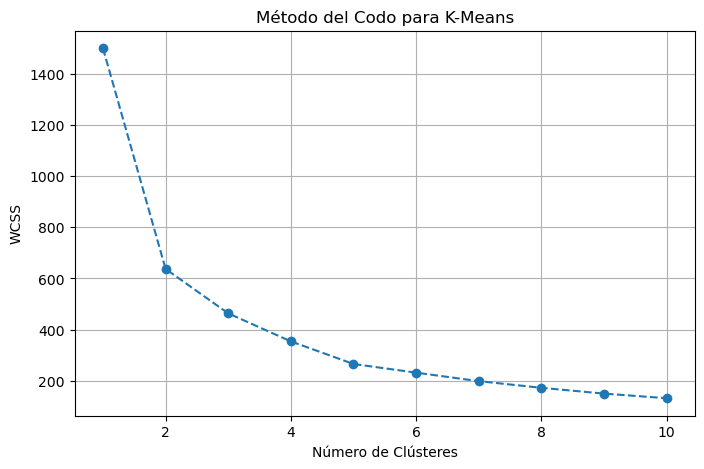


--- Conteo de puntos por Clúster (K-Means con 3 clústeres) ---
Cluster
0    222
1     17
2     11
Name: count, dtype: int64

--- Perfil de los Clústeres (medias de las variables originales) ---
         Tipo de Cambio        Merval  % Crecimiento Merval  Inflación  \
Cluster                                                                  
0             21.058495  1.603145e+04              2.572472   1.651351   
1            230.377065  3.410194e+05             14.979118   7.758824   
2            897.095500  1.430949e+06              8.837299   9.300000   

                  PBI  Tasa de interes del BCRA  
Cluster                                          
0        1.059427e+07                  1.758442  
1        1.664941e+08                 29.113555  
2        5.633994e+08                 26.145952  


c:\Users\Brian Emanuel Rios\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


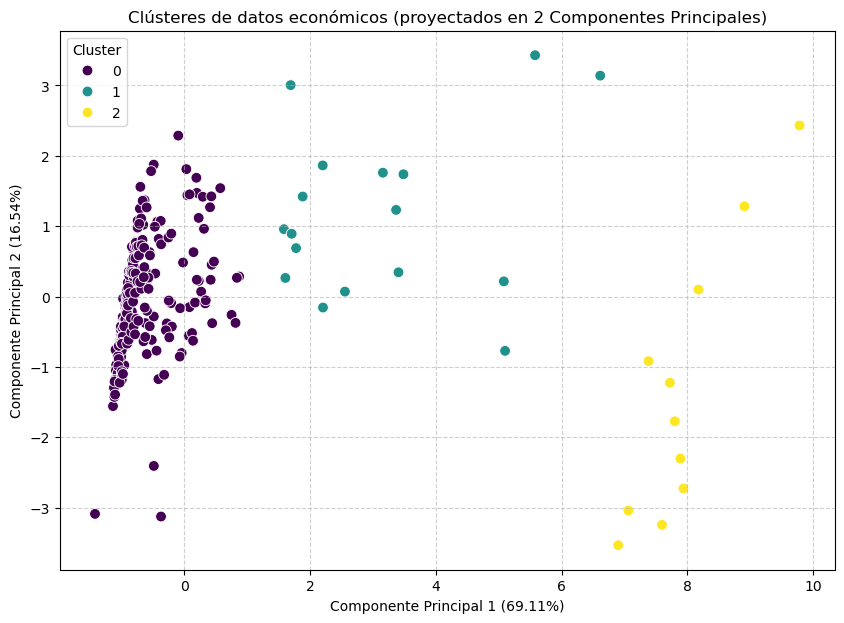


--- Aplicando PCA ---

Varianza explicada por cada Componente Principal:
PC1: 69.11%
PC2: 16.54%
PC3: 11.95%
PC4: 2.17%
PC5: 0.16%
PC6: 0.07%


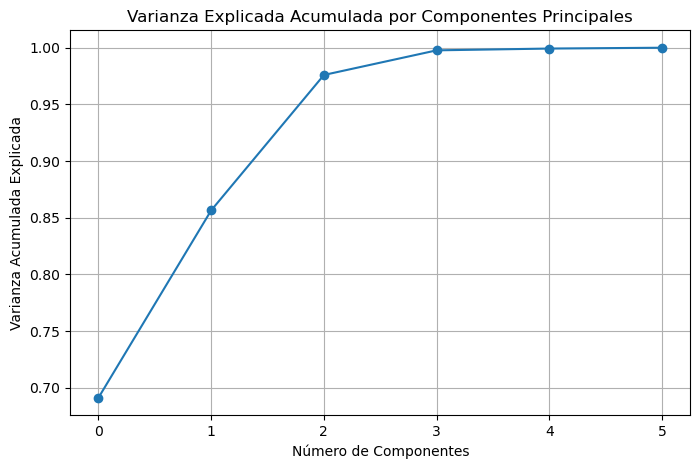


--- Cargas de las Componentes Principales ---
                               PC1       PC2       PC3       PC4       PC5  \
Tipo de Cambio            0.471662 -0.194458 -0.207505 -0.163923  0.734376   
Merval                    0.458355 -0.215041 -0.329668 -0.019613 -0.664770   
% Crecimiento Merval      0.139825  0.886756 -0.439858 -0.007653  0.022811   
Inflación                 0.392370  0.230718  0.595655 -0.644665 -0.129774   
PBI                       0.466168 -0.211916 -0.266644  0.059267 -0.017154   
Tasa de interes del BCRA  0.420271  0.177396  0.478415  0.744030  0.033430   

                               PC6  
Tipo de Cambio           -0.361227  
Merval                   -0.438957  
% Crecimiento Merval      0.007732  
Inflación                 0.074667  
PBI                       0.814170  
Tasa de interes del BCRA -0.091235  


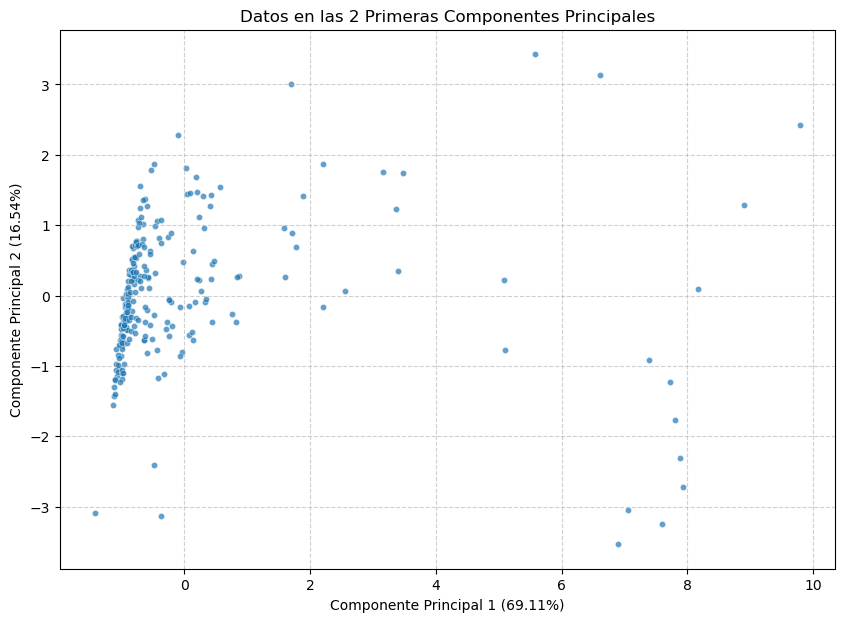

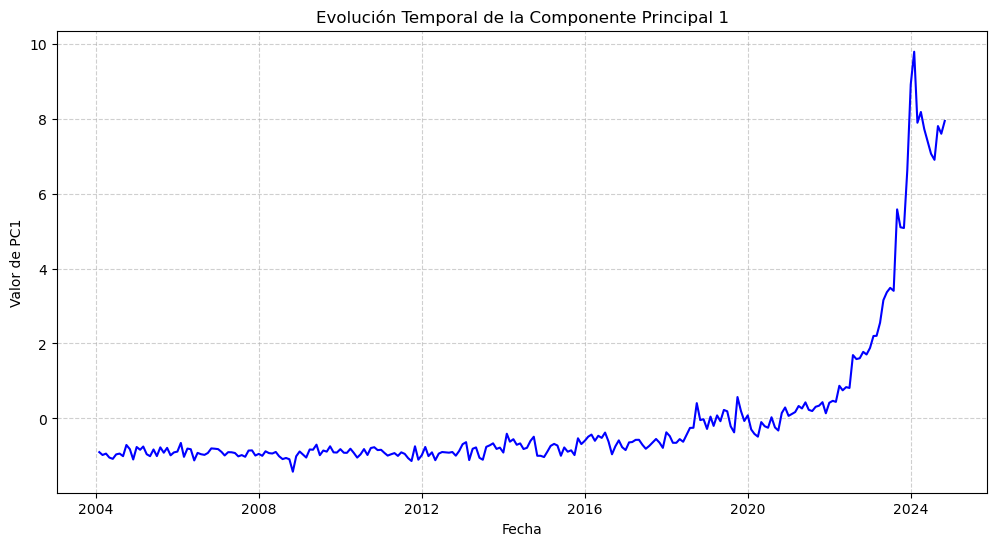

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import numpy as np # Para manejar NaNs si aún hubiera


# --- Datos para la aplicación de ML ---
# Selecciona solo las columnas numéricas que quieres analizar
# Asegúrate de manejar cualquier NaN residual en estas columnas antes de escalar
# (Ej: df_combinado_mensual.fillna(method='ffill', inplace=True) o .dropna())
df_ml = df_combinado_mensual[['Tipo de Cambio', 'Merval', '% Crecimiento Merval',
                               'Inflación', 'PBI', 'Tasa de interes del BCRA']].copy()

# Eliminar filas con NaN si quedaron algunas (o rellenar como prefieras)
df_ml.dropna(inplace=True)

# Escalar los datos (es crucial para Clustering y PCA)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_ml)
df_scaled = pd.DataFrame(df_scaled, columns=df_ml.columns, index=df_ml.index)

# --- EJEMPLO DE APLICACIÓN: Clustering con K-Means ---
print("\n--- Aplicando K-Means Clustering ---")
# Método del codo para encontrar el número óptimo de clústeres
wcss = [] # Suma de cuadrados dentro del clúster
for i in range(1, 11): # Prueba de 1 a 10 clústeres
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # n_init para evitar warning
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clústeres')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# Suponiendo que el método del codo sugiere 3 clústeres (por ejemplo)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
df_ml['Cluster'] = kmeans.fit_predict(df_scaled)

print(f"\n--- Conteo de puntos por Clúster (K-Means con {n_clusters} clústeres) ---")
print(df_ml['Cluster'].value_counts())

print("\n--- Perfil de los Clústeres (medias de las variables originales) ---")
# Para entender qué significa cada clúster
cluster_summary = df_ml.groupby('Cluster').mean()
print(cluster_summary)

# Visualización de clústeres (usando PCA para 2D si hay muchas variables)
if df_scaled.shape[1] > 2:
    pca = PCA(n_components=2)
    components = pca.fit_transform(df_scaled)
    df_components = pd.DataFrame(data=components, columns=['PC1', 'PC2'], index=df_ml.index)
    df_components['Cluster'] = df_ml['Cluster']

    plt.figure(figsize=(10, 7))
    sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_components, palette='viridis', legend='full', s=60)
    plt.title('Clústeres de datos económicos (proyectados en 2 Componentes Principales)')
    plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
    plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


# --- EJEMPLO DE APLICACIÓN: Análisis de Componentes Principales (PCA) ---
print("\n--- Aplicando PCA ---")
pca = PCA(n_components=None) # Ajustar a todas las componentes posibles
pca.fit(df_scaled)

# Varianza explicada por cada componente
explained_variance_ratio = pca.explained_variance_ratio_
print("\nVarianza explicada por cada Componente Principal:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC{i+1}: {ratio*100:.2f}%")

# Gráfico de la varianza explicada acumulada
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(explained_variance_ratio), marker='o', linestyle='-')
plt.title('Varianza Explicada Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada Explicada')
plt.grid(True)
plt.show()

# Cargas de las componentes (para interpretar qué representa cada PC)
pca_loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(explained_variance_ratio))], index=df_scaled.columns)
print("\n--- Cargas de las Componentes Principales ---")
print(pca_loadings)

# Si quieren visualizar los datos transformados en las 2 primeras PCs
pca_2d = PCA(n_components=2)
components_2d = pca_2d.fit_transform(df_scaled)
df_pca_2d = pd.DataFrame(data=components_2d, columns=['PC1', 'PC2'], index=df_ml.index)

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', data=df_pca_2d, s=20, alpha=0.7)
plt.title('Datos en las 2 Primeras Componentes Principales')
plt.xlabel(f'Componente Principal 1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Componente Principal 2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Para visualizar la evolución temporal de las PCs (ej. PC1)
plt.figure(figsize=(12, 6))
plt.plot(df_pca_2d.index, df_pca_2d['PC1'], label='Componente Principal 1', color='blue')
plt.title('Evolución Temporal de la Componente Principal 1')
plt.xlabel('Fecha')
plt.ylabel('Valor de PC1')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

MSE: 600170419.0616739
R²: 0.9867785929456379
Coeficientes: [ 2.05718303e+02  1.08519074e+03  2.30096080e-03 -2.32668335e+03]


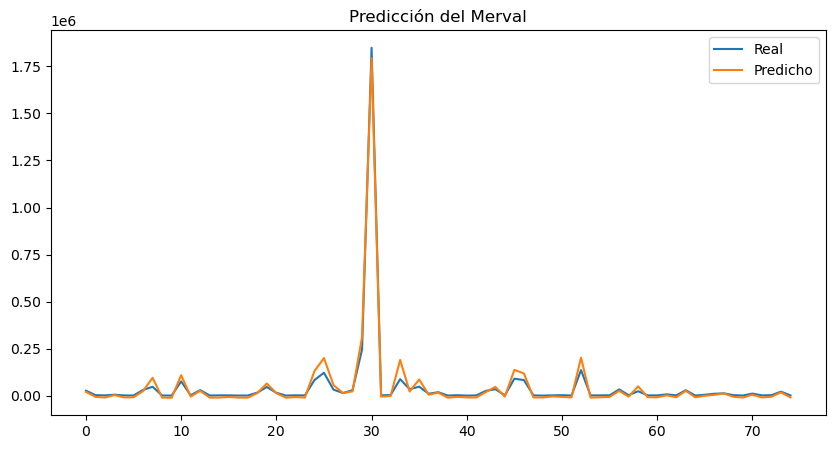

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# df_ml ya está definido correctamente, no es necesario definir df
# 2. Variables
X = df_combinado_mensual[['Tipo de Cambio', 
            'Inflación', 'PBI', 'Tasa de interes del BCRA']]
y = df_combinado_mensual['Merval']

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=444)

# 4. Modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# 5. Predicción
y_pred = modelo.predict(X_test)

# 6. Evaluación
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))
print("Coeficientes:", modelo.coef_)

# 7. Visualización
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Real')
plt.plot(y_pred, label='Predicho')
plt.legend()
plt.title("Predicción del Merval")
plt.show()


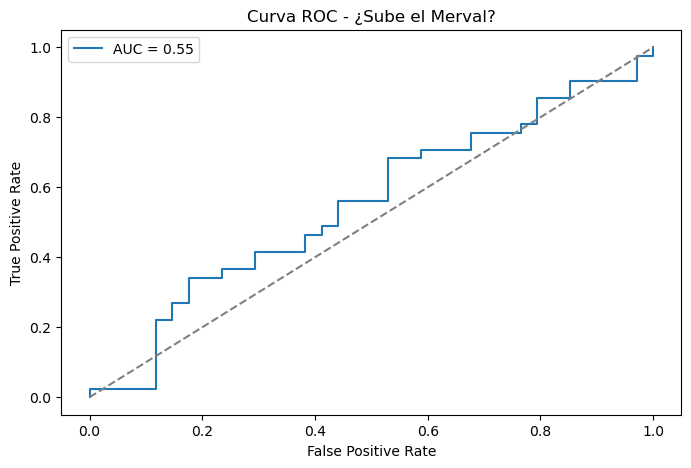

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt

# 1. Crear variable binaria: sube (1) o no sube (0)
df_combinado_mensual['merval_sube'] = (df_combinado_mensual['Merval'].diff() > 0).astype(int)
df_combinado_mensual.dropna(inplace=True)

# 2. Variables
X = df_combinado_mensual[['Tipo de Cambio', 
            'Inflación', 'PBI', 'Tasa de interes del BCRA']]
y = df_combinado_mensual['merval_sube']

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=444)

# 4. Modelo
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

# 5. Probabilidades
y_proba = logreg.predict_proba(X_test)[:, 1]

# 6. Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - ¿Sube el Merval?")
plt.legend()
plt.show()


In [ ]:
print(df_combinado_mensual.columns.tolist())


['Tipo de Cambio', 'Merval', '% Crecimiento Merval', 'Inflación', 'PBI', 'indice_tiempo', 'Tasa de interes del BCRA', 'merval_sube']


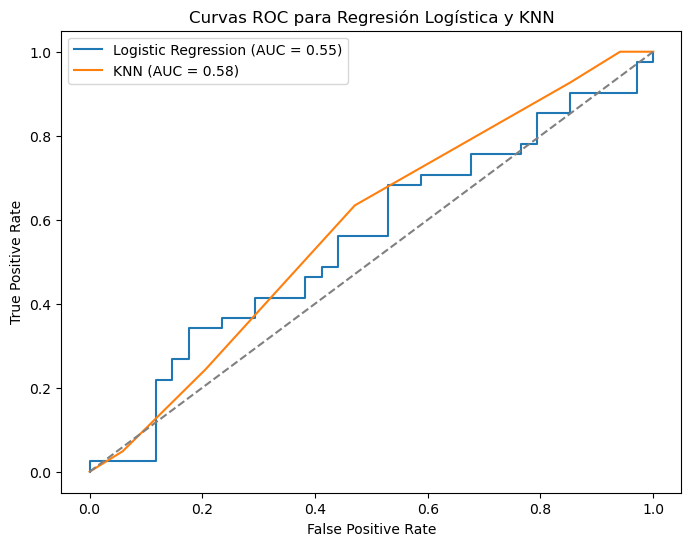

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Supongamos que ya tenés el dataframe df_combinado_mensual con las variables preparadas
# Variables predictoras y variable objetivo
X = df_combinado_mensual[['Tipo de Cambio',
                          'Inflación', 'PBI', 'Tasa de interes del BCRA']]
y = df_combinado_mensual['merval_sube']

# División train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=444)

# Modelo 1: Regresión Logística
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_proba_logreg = logreg.predict_proba(X_test)[:, 1]
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_proba_logreg)
auc_logreg = roc_auc_score(y_test, y_proba_logreg)

# Modelo 2: K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_proba_knn = knn.predict_proba(X_test)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
auc_knn = roc_auc_score(y_test, y_proba_knn)

# Plot curvas ROC
plt.figure(figsize=(8,6))
plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {auc_logreg:.2f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.2f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC para Regresión Logística y KNN')
plt.legend()
plt.show()
